In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_combined",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    color_mode="rgb"  
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_combined",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    color_mode="rgb"   
)

Found 122768 files belonging to 124 classes.
Using 98215 files for training.
Found 122768 files belonging to 124 classes.
Using 24553 files for validation.


In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

In [11]:
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B3, preprocess_input
from tensorflow.keras import layers, models

base_model = EfficientNetV2B3(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 344s 7us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-b3 (Functional)       │ (None, 7, 7, 1536)          │      12,930,622 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1536)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1536)                │           6,144 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1536)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 124)                 │         190,588 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,127,354 (50.08 MB)

 Trainable params: 193,660 (756.48 KB)

 Non-trainable params: 12,933,694 (49.34 MB)

In [12]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2207s 714ms/step - accuracy: 0.4456 - loss: 2.4208 - val_accuracy: 0.6359 - val_loss: 1.4227
Epoch 2/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2063s 672ms/step - accuracy: 0.5255 - loss: 1.9537 - val_accuracy: 0.6525 - val_loss: 1.3350
Epoch 3/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2068s 673ms/step - accuracy: 0.5422 - loss: 1.8450 - val_accuracy: 0.6622 - val_loss: 1.2890
Epoch 4/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2062s 672ms/step - accuracy: 0.5549 - loss: 1.7660 - val_accuracy: 0.6695 - val_loss: 1.2592
Epoch 5/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2092s 681ms/step - accuracy: 0.5629 - loss: 1.7221 - val_accuracy: 0.6738 - val_loss: 1.2437
Epoch 6/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2144s 698ms/step - accuracy: 0.5654 - loss: 1.7030 - val_accuracy: 0.6756 - val_loss: 1.2382
Epoch 7/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2150s 700ms/step - accuracy: 0.5723 - loss: 1.6750 - val_accuracy: 0.6809 - val_loss: 1.2310
Epoch 8/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2148s 700ms/s

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-25]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2301s 741ms/step - accuracy: 0.6051 - loss: 1.5282 - val_accuracy: 0.7119 - val_loss: 1.1056
Epoch 2/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2285s 744ms/step - accuracy: 0.6217 - loss: 1.4519 - val_accuracy: 0.7193 - val_loss: 1.0757
Epoch 3/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2264s 738ms/step - accuracy: 0.6316 - loss: 1.4071 - val_accuracy: 0.7259 - val_loss: 1.0495
Epoch 4/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2264s 737ms/step - accuracy: 0.6409 - loss: 1.3684 - val_accuracy: 0.7290 - val_loss: 1.0323
Epoch 5/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2252s 734ms/step - accuracy: 0.6475 - loss: 1.3453 - val_accuracy: 0.7339 - val_loss: 1.0143
Epoch 6/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2241s 730ms/step - accuracy: 0.6521 - loss: 1.3236 - val_accuracy: 0.7358 - val_loss: 1.0065
Epoch 7/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2240s 730ms/step - accuracy: 0.6566 - loss: 1.3007 - val_accuracy: 0.7384 - val_loss: 0.9921
Epoch 8/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2238s 729ms/s

In [14]:
import matplotlib.pyplot as plt

acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs = range(1, len(acc) + 1)

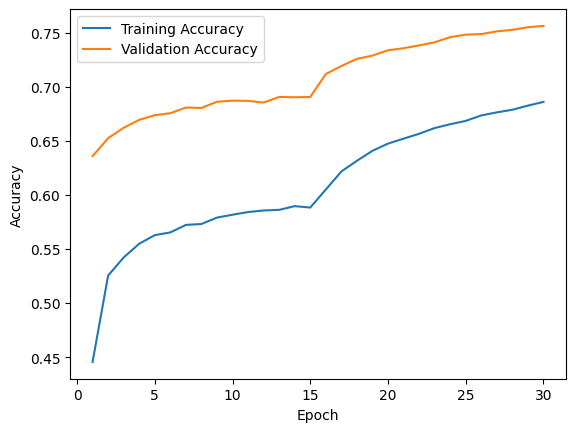

In [15]:
plt.figure()
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

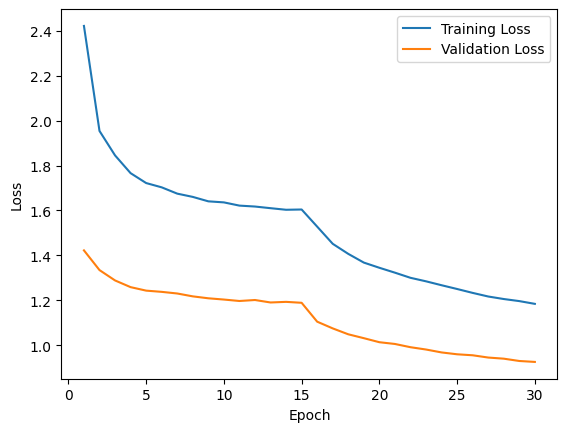

In [16]:
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [17]:
for layer in base_model.layers[:-10]:
    layer.trainable = False

In [18]:
optimizer=tf.keras.optimizers.Adam(1e-6)

In [19]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2428s 791ms/step - accuracy: 0.6872 - loss: 1.1749 - val_accuracy: 0.7591 - val_loss: 0.9204
Epoch 2/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2493s 812ms/step - accuracy: 0.6916 - loss: 1.1629 - val_accuracy: 0.7601 - val_loss: 0.9144
Epoch 3/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2488s 810ms/step - accuracy: 0.6925 - loss: 1.1560 - val_accuracy: 0.7630 - val_loss: 0.9053
Epoch 4/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2483s 809ms/step - accuracy: 0.6961 - loss: 1.1440 - val_accuracy: 0.7635 - val_loss: 0.9024
Epoch 5/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2493s 812ms/step - accuracy: 0.6978 - loss: 1.1300 - val_accuracy: 0.7634 - val_loss: 0.8991
Epoch 6/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2576s 839ms/step - accuracy: 0.7003 - loss: 1.1232 - val_accuracy: 0.7661 - val_loss: 0.8933
Epoch 7/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2688s 875ms/step - accuracy: 0.7019 - loss: 1.1157 - val_accuracy: 0.7678 - val_loss: 0.8887
Epoch 8/15
3070/3070 ━━━━━━━━━━━━━━━━━━━━ 2567s 836ms/s

In [20]:
model.save("food_efficientnet_v2.h5")

In [21]:
print(class_names)

['apple_pie', 'ayam_goreng', 'ayam_pop', 'baby_back_ribs', 'baklava', 'bakso', 'bebek_betutu', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'burger', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'daging_rendang', 'dendeng_batokok', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'gado_gado', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gudeg', 'gulai_ikan', 'gulai_tambusu', 'gulai_tunjang', 'gyoza', 'hamburger', 'hot

In [22]:
with open("labels.txt", "w") as f:
    for label in class_names:
        f.write(label + "\n")